In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter #Used for finding majority class in ID3

In [2]:
# Load dataset
df = pd.read_csv("utrecht_recruitment.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Keep only necessary columns
df = df[[
    "Age(feature, sensitive))",
    "Gender(feature,sensitive)",
    "testresult(feature)",
    "Should-hire(target)"
]]

# Rename neatly
df = df.rename(columns={
    "Age(feature, sensitive))": "age",
    "Gender(feature,sensitive)": "gender",
    "testresult(feature)": "test_result",
    "Should-hire(target)": "hired"
})

# Convert target to integer 
# Entropy requires numeric class labels.
df["hired"] = df["hired"].astype(int)

print(df.head())
print("\nClass Distribution:")
print(df["hired"].value_counts())

   age gender  test_result  hired
0   22   male          2.0      1
1   26   male          1.5      1
2   28   male          2.0      1
3   28   male          1.5      1
4   32   male          2.0      1

Class Distribution:
hired
0    150
1     75
Name: count, dtype: int64


In [3]:
def age_group(age):
    if age < 25:
        return "<25"
    elif age <= 35:
        return "25-35"
    else:
        return "35+"

df["age_group"] = df["age"].apply(age_group)

In [4]:
X = df[["age", "gender", "test_result"]].copy()
y = df["hired"].copy()

# Convert all features to string for ID3
for col in X.columns:
    X[col] = X[col].astype(str)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [6]:
def entropy(y):
    y = np.array(y)
    unique_vals = np.unique(y)
    counts = [np.sum(y == val) for val in unique_vals]
    probabilities = np.array(counts) / len(y)
    return -np.sum([p * np.log2(p) for p in probabilities if p > 0])

In [7]:
def information_gain(X_column, y):
    parent_entropy = entropy(y)
    values = np.unique(X_column)
    weighted_entropy = 0

    for value in values:
        subset_y = y[X_column == value]
        weighted_entropy += (len(subset_y) / len(y)) * entropy(subset_y)

    return parent_entropy - weighted_entropy

In [8]:
def id3(X, y, depth=0, max_depth=5, min_samples=5):

    if len(np.unique(y)) == 1:
        return y.iloc[0]

    if len(X.columns) == 0:
        return Counter(y).most_common(1)[0][0]

    if depth >= max_depth or len(y) < min_samples:
        return Counter(y).most_common(1)[0][0]

    gains = [information_gain(X[col], y) for col in X.columns]
    best_feature = X.columns[np.argmax(gains)]

    tree = {best_feature: {}}

    for value in np.unique(X[best_feature]):
        subset_X = X[X[best_feature] == value].drop(columns=[best_feature])
        subset_y = y[X[best_feature] == value]
        subtree = id3(subset_X, subset_y, depth+1, max_depth, min_samples)
        tree[best_feature][value] = subtree

    return tree

In [9]:
tree = id3(X_train, y_train)
print("\nTrained Decision Tree:")
print(tree)


Trained Decision Tree:
{'test_result': {'0.0': np.int64(0), '0.5': np.int64(0), '1.0': {'age': {'21': np.int64(0), '22': 1, '23': np.int64(0), '24': 1, '25': np.int64(1), '26': 1, '29': 1, '30': np.int64(0), '31': np.int64(0), '32': np.int64(0), '33': np.int64(1), '35': 0, '36': np.int64(0), '37': np.int64(0), '38': np.int64(0), '39': np.int64(0), '40': np.int64(0), '41': np.int64(0), '42': np.int64(0), '43': np.int64(0), '44': np.int64(0), '46': 0, '47': np.int64(0), '48': 0, '49': np.int64(0)}}, '1.5': {'age': {'20': np.int64(1), '21': np.int64(1), '22': np.int64(0), '23': np.int64(1), '24': np.int64(1), '25': np.int64(1), '26': 0, '27': np.int64(0), '28': 0, '29': np.int64(1), '30': np.int64(0), '31': np.int64(1), '33': 1, '34': np.int64(0), '35': np.int64(1), '36': {'gender': {'female': np.int64(1), 'male': 0}}, '38': 1, '39': np.int64(0), '40': 0, '41': np.int64(1), '42': 0, '43': np.int64(0), '44': 0, '45': np.int64(0), '46': np.int64(1), '47': np.int64(0), '48': np.int64(0), '4

In [10]:
def predict(sample, tree):
    if not isinstance(tree, dict):
        return tree

    feature = list(tree.keys())[0]
    value = sample.get(feature)

    if value in tree[feature]:
        return predict(sample, tree[feature][value])
    else:
        return 0

def predict_dataset(X, tree):
    return X.apply(lambda row: predict(row, tree), axis=1)

y_pred = predict_dataset(X_test, tree)

In [11]:
TP = sum((y_test == 1) & (y_pred == 1))
TN = sum((y_test == 0) & (y_pred == 0))
FP = sum((y_test == 0) & (y_pred == 1))
FN = sum((y_test == 1) & (y_pred == 0))

accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

print("\nPerformance Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Performance Metrics:
Accuracy: 0.7352941176470589
Precision: 0.6923076923076923
Recall: 0.391304347826087
F1-score: 0.5


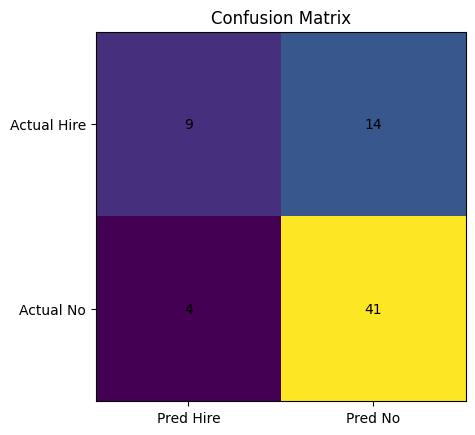

In [12]:
conf_matrix = np.array([[TP, FN],
                        [FP, TN]])

plt.figure()
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.xticks([0,1], ["Pred Hire","Pred No"])
plt.yticks([0,1], ["Actual Hire","Actual No"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.show()


Feature Importance:
test_result : 0.24548605956111613
age : 0.21525563042619678
gender : 0.02275385617524739


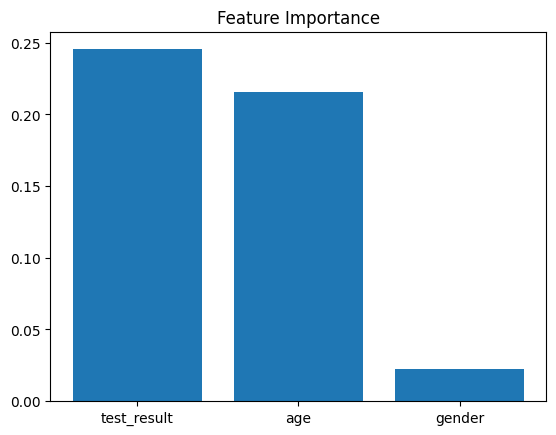

In [13]:
def calculate_feature_importance(X, y):
    importance = {}
    for col in X.columns:
        importance[col] = information_gain(X[col], y)
    return sorted(importance.items(), key=lambda x: x[1], reverse=True)

importance = calculate_feature_importance(X_train, y_train)

print("\nFeature Importance:")
for feature, score in importance:
    print(feature, ":", score)

# Plot
features = [i[0] for i in importance]
scores = [i[1] for i in importance]

plt.figure()
plt.bar(features, scores)
plt.title("Feature Importance")
plt.show()

In [14]:
test_df = X_test.copy()
test_df["actual"] = y_test
test_df["predicted"] = y_pred
test_df["gender"] = df.loc[X_test.index, "gender"]
test_df["age_group"] = df.loc[X_test.index, "age_group"]

In [15]:
print("\nDemographic Parity - Gender")
for group in test_df["gender"].unique():
    rate = test_df[test_df["gender"] == group]["predicted"].mean()
    print(group, "Hiring Rate:", rate)


Demographic Parity - Gender
female Hiring Rate: 0.18518518518518517
male Hiring Rate: 0.1951219512195122


In [16]:
print("\nEqual Opportunity - Gender")
for group in test_df["gender"].unique():
    group_data = test_df[test_df["gender"] == group]
    TP_g = sum((group_data["actual"] == 1) & (group_data["predicted"] == 1))
    FN_g = sum((group_data["actual"] == 1) & (group_data["predicted"] == 0))
    tpr = TP_g / (TP_g + FN_g) if (TP_g + FN_g) != 0 else 0
    print(group, "TPR:", tpr)


Equal Opportunity - Gender
female TPR: 0.4
male TPR: 0.3888888888888889
